## 1. Завантаження feature_matrix.parquet


In [1]:
import sys
from pathlib import Path

project_root = Path('..').resolve()
sys.path.append(str(project_root))

import pandas as pd
import numpy as np
import plotly.express as px
from sklearn.preprocessing import RobustScaler

from src.pipelines import wfv_orchestrator

processed_dir = project_root / 'data' / 'processed'
feature_df = pd.read_parquet(processed_dir / 'feature_matrix.parquet')
target_h1 = pd.read_parquet(processed_dir / 'target_h1.parquet')
target_series = target_h1.iloc[:, 0]

## 2. Визначення max_lag_order — AIC plot по p від 1 до 20


In [2]:
from statsmodels.tsa.ar_model import AutoReg

series = target_series.dropna().values
aic_values = {}
for p in range(1, 21):
    model = AutoReg(series, lags=p, old_names=False).fit()
    aic_values[p] = model.aic

aic_df = pd.DataFrame({'lag': list(aic_values.keys()), 'aic': list(aic_values.values())})
fig = px.line(aic_df, x='lag', y='aic', markers=True, title='AIC by Lag Order')
fig.show()


## 3. Демонстрація feature selection на першому WFV fold


In [3]:
config = wfv_orchestrator.WFVConfig()
train_end = config.w_train
X_train = feature_df.iloc[:train_end]
y_train = target_series.loc[X_train.index]

scaler = RobustScaler()
X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train),
    index=X_train.index,
    columns=X_train.columns,
)

granger_features, f_stats = wfv_orchestrator._select_features_granger(
    X_train_scaled,
    y_train,
    config,
)
vif_features = wfv_orchestrator._select_features_vif(X_train_scaled[granger_features], config)
corr_features = wfv_orchestrator._select_features_correlation(
    X_train_scaled[vif_features],
    f_stats,
    config,
)
shap_features = wfv_orchestrator._select_features_shap(
    X_train_scaled[corr_features],
    y_train,
    config,
)

summary = pd.DataFrame({
    'stage': ['raw', 'granger', 'vif', 'pearson', 'shap'],
    'n_features': [
        X_train.shape[1],
        len(granger_features),
        len(vif_features),
        len(corr_features),
        len(shap_features),
    ]
})
summary



Granger Causality
number of lags (no zero) 1
ssr based F test:         F=1.9561  , p=0.1622  , df_denom=996, df_num=1
ssr based chi2 test:   chi2=1.9620  , p=0.1613  , df=1
likelihood ratio test: chi2=1.9601  , p=0.1615  , df=1
parameter F test:         F=1.9561  , p=0.1622  , df_denom=996, df_num=1

Granger Causality
number of lags (no zero) 2
ssr based F test:         F=2.0697  , p=0.1268  , df_denom=994, df_num=2
ssr based chi2 test:   chi2=4.1561  , p=0.1252  , df=2
likelihood ratio test: chi2=4.1475  , p=0.1257  , df=2
parameter F test:         F=3.0506  , p=0.0478  , df_denom=994, df_num=2

Granger Causality
number of lags (no zero) 3
ssr based F test:         F=0.3176  , p=0.8127  , df_denom=992, df_num=3
ssr based chi2 test:   chi2=0.9576  , p=0.8115  , df=3
likelihood ratio test: chi2=0.9572  , p=0.8116  , df=3
parameter F test:         F=2.3634  , p=0.0697  , df_denom=992, df_num=3

Granger Causality
number of lags (no zero) 4
ssr based F test:         F=0.9872  , p=0.4135  

2026-03-16 21:01:37.362 | INFO     | src.pipelines.wfv_orchestrator:_select_features_vif:177 - Removed brent_return_rollmean20 due to high VIF (20.997722890273117)
2026-03-16 21:01:37.394 | INFO     | src.pipelines.wfv_orchestrator:_select_features_vif:177 - Removed brent_return_rollmean10 due to high VIF (11.637153863427681)
2026-03-16 21:01:37.427 | INFO     | src.pipelines.wfv_orchestrator:_select_features_vif:177 - Removed brent_return_rollstd5 due to high VIF (7.284034628510783)
2026-03-16 21:01:37.453 | INFO     | src.pipelines.wfv_orchestrator:_select_features_vif:177 - Removed brent_return_rollmean5 due to high VIF (6.846585095870799)


ssr based F test:         F=1.2852  , p=0.2405  , df_denom=972, df_num=9
ssr based chi2 test:   chi2=11.7930 , p=0.2252  , df=9
likelihood ratio test: chi2=11.7234 , p=0.2294  , df=9
parameter F test:         F=1.2852  , p=0.2405  , df_denom=972, df_num=9

Granger Causality
number of lags (no zero) 10
ssr based F test:         F=1.3101  , p=0.2199  , df_denom=969, df_num=10
ssr based chi2 test:   chi2=13.3853 , p=0.2029  , df=10
likelihood ratio test: chi2=13.2956 , p=0.2076  , df=10
parameter F test:         F=1.3101  , p=0.2199  , df_denom=969, df_num=10

Granger Causality
number of lags (no zero) 1
ssr based F test:         F=3.8555  , p=0.0499  , df_denom=996, df_num=1
ssr based chi2 test:   chi2=3.8671  , p=0.0492  , df=1
likelihood ratio test: chi2=3.8596  , p=0.0495  , df=1
parameter F test:         F=3.8555  , p=0.0499  , df_denom=996, df_num=1

Granger Causality
number of lags (no zero) 2
ssr based F test:         F=4.5763  , p=0.0105  , df_denom=993, df_num=2
ssr based chi2 t

2026-03-16 21:01:37.476 | INFO     | src.pipelines.wfv_orchestrator:_select_features_vif:177 - Removed brent_return_rollstd20 due to high VIF (6.026159177989306)
/home/majestic/projects/OilOracle/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


,stage,n_features
0,raw,28
1,granger,24
2,vif,19
3,pearson,18
4,shap,15


## 4. SHAP beeswarm plot для LightGBM на першому fold


<Axes: xlabel='SHAP value (impact on model output)'>

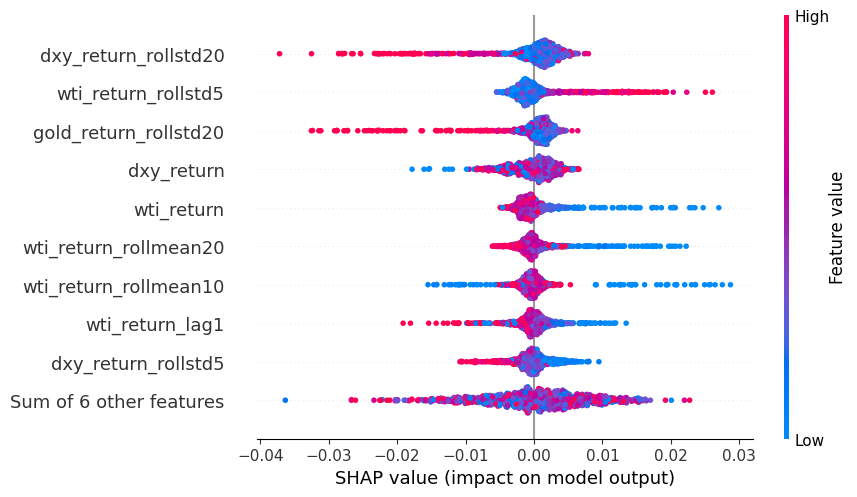

In [4]:
import lightgbm as lgb
import shap

model = lgb.LGBMRegressor(n_estimators=200, learning_rate=0.05, num_leaves=31)
model.fit(X_train_scaled[shap_features], y_train)

explainer = shap.TreeExplainer(model)
shap_values = explainer(X_train_scaled[shap_features])
shap.plots.beeswarm(shap_values, show=False)

## 5. Feature importance evolution (heatmap: fold × feature)


In [8]:
import json
from pathlib import Path
from plotly.subplots import make_subplots

project_root = Path('..').resolve()
processed_dir = project_root / 'data' / 'processed'

audit_files = sorted(processed_dir.glob('audit_random_forest_1.json'))
if not audit_files:
    print('No audit logs found. Run WFV first.')
else:
    audit = json.loads(audit_files[0].read_text())
    feature_sets = []
    fold_ids = []
    for entry in audit:
        fold_ids.append(entry['fold_idx'])
        feature_sets.append(entry['selected_features'])
    all_features = sorted({feat for feats in feature_sets for feat in feats})
    matrix = np.zeros((len(fold_ids), len(all_features)))
    for i, feats in enumerate(feature_sets):
        for feat in feats:
            matrix[i, all_features.index(feat)] = 1
    fig = px.imshow(matrix, labels={'x': 'feature', 'y': 'fold', 'color': 'selected'},
                   x=all_features, y=fold_ids, title='Feature Selection Evolution')
    fig.show()